# Benchmark: Set-distance metrics (e.g. hausdorff) for random point sets without optimization

In [2]:
import numpy as np
import pandas as pd
import plotnine as p9
from tqdm import tqdm, trange
import sys
import os
project_root = os.path.abspath('..')          # one level up from notebooks' directory
if project_root not in sys.path:
    sys.path.append(project_root)
from auction_module.bundling_and_bidding.fitness_functions.vrp_learn.distance import my_convex_hull_jaccard_distance, my_hausdorff_distance, my_MinWBMP, my_dice_similarity_coefficient, my_tsp_obj_val_diff, my_tsp_hull_jaccard_distance, my_modified_hausdorff_distance

In [6]:
rng = np.random.default_rng(1)

x_min, x_max, y_min, y_max = 0, 100, 0, 100
num_draws = 10000

records = []
for num_a in [4, 8]:
    for frac_b in [0.5, 1, 2]:
        num_b = int(num_a * frac_b)
        for draw in trange(num_draws, desc=f'{num_a} true vs. {num_b} predicted'):
            params = {
                'x_min': x_min,
                'x_max': x_max,
                'y_min': y_min,
                'y_max': y_max,
                'num_a': num_a,
                'num_b': num_b,
                'frac_b': frac_b 
            }
            set_a = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_a, 2))
            set_b = rng.uniform((x_min, y_min), (x_max, y_max), size=(num_b, 2))
            df = pd.DataFrame(np.concat([set_a, set_b], axis=0), columns=['x', 'y'])
            # df['label'] = ["a"] * num_a + ["b"] * num_b
            # p9.qplot('x', 'y', df, geom='point', fill='label', size=4)
            metrics = {
                'hausdorff': my_hausdorff_distance(set_a, set_b),
                'modified hausdorff': my_modified_hausdorff_distance(set_a, set_b),
                'jaccard': my_convex_hull_jaccard_distance(set_a, set_b),
                # 'MinWBMP': my_MinWBMP(set_a, set_b),
                # 'dice': my_dice_similarity_coefficient(set_a, set_b),
                # 'TSP objective': my_tsp_obj_val_diff(set_a, set_b),
                # 'TSP hull': my_tsp_hull_jaccard_distance(set_a, set_b)
            }
            metrics['normalized hausdorff'] = metrics['hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            metrics['normalized modified hausdorff'] = metrics['modified hausdorff']/np.sqrt((x_max-x_min)**2 + (y_max - y_min)**2)
            record = {**metrics, **params}
            records.append(record)
df = pd.DataFrame.from_records(records)
df

8 true vs. 16 predicted: 100%|██████████| 10000/10000 [00:01<00:00, 6782.09it/s]


,hausdorff,modified hausdorff,jaccard,normalized hausdorff,normalized modified hausdorff,x_min,x_max,y_min,y_max,num_a,num_b,frac_b
0,73.472918,45.444758,1.000000,0.519532,0.321343,0,100,0,100,4,2,0.5
1,62.841892,47.560341,1.000000,0.444359,0.336302,0,100,0,100,4,2,0.5
2,66.949166,49.338416,1.000000,0.473402,0.348875,0,100,0,100,4,2,0.5
3,58.715824,40.606389,1.000000,0.415184,0.287131,0,100,0,100,4,2,0.5
4,78.860367,58.765434,1.000000,0.557627,0.415534,0,100,0,100,4,2,0.5
...,...,...,...,...,...,...,...,...,...,...,...,...
59995,49.161357,25.998851,0.548495,0.347623,0.183840,0,100,0,100,8,16,2.0
59996,48.489303,17.076079,0.462379,0.342871,0.120746,0,100,0,100,8,16,2.0
59997,48.139301,28.704155,0.619996,0.340396,0.202969,0,100,0,100,8,16,2.0
59998,49.579407,23.476911,0.650338,0.350579,0.166007,0,100,0,100,8,16,2.0


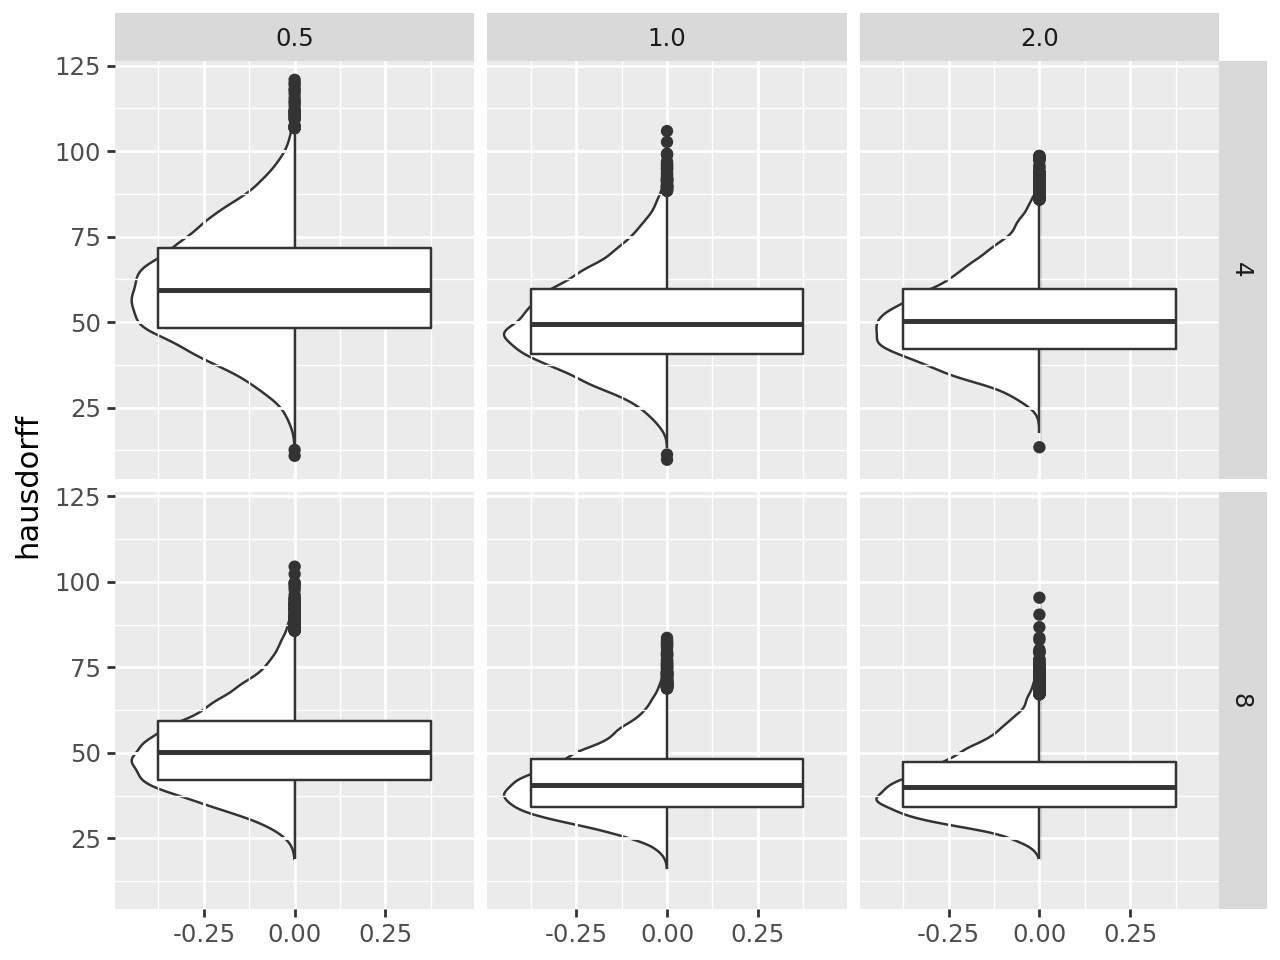

In [7]:
(p9.ggplot( df, p9.aes(y='hausdorff'))
+ p9.geom_violin(style='left')
+ p9.geom_boxplot()
+ p9.facet_grid('num_a', 'frac_b')
)

In [8]:
df.groupby(['frac_b', 'num_a']).describe()['hausdorff']

count       mean        std        min        25%        50%  \
frac_b num_a                                                                   
0.5    4      10000.0  60.256547  16.490994  10.938535  48.349970  59.492238   
       8      10000.0  51.455723  12.767219  19.015350  42.016511  50.213602   
1.0    4      10000.0  50.606022  13.833841   9.789594  40.675849  49.444780   
       8      10000.0  41.801513  10.179594  15.950584  34.313900  40.533405   
2.0    4      10000.0  51.487219  12.790389  13.440445  42.128553  50.254672   
       8      10000.0  41.427913   9.806737  18.841852  34.211413  40.011443   

                    75%         max  
frac_b num_a                         
0.5    4      71.667630  120.847094  
       8      59.444285  104.442542  
1.0    4      59.728119  105.859142  
       8      48.103522   83.629370  
2.0    4      59.571719   98.575139  
       8      47.380505   95.369018